# RflyMAD-Full v2 — Çalıştırılmış deney özeti

**Tarih:** 22 Temmuz 2026  
**Kapsam:** veri/parser/truth denetimleri, normal-only temporal AE, TCN development
smoke, Wind/Real robustness adayları ve R4 convergence takibi.  
**Güvenlik sınırı:** locked-test feature dosyaları okunmadı; sonuçlar yalnız
development araştırma bulgusudur ve operasyonel iddia oluşturmaz.

Bu notebook çıktı hücreleriyle birlikte commit edilmiştir. Yeniden çalıştırıldığında
yalnız `notebooks/data/rflymad_v2/` altındaki küçük, sabitlenmiş özetleri okur; model,
parquet veya kilitli test dosyalarına erişmez.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "notebooks" / "data" / "rflymad_v2").exists():
    ROOT = ROOT.parent
DATA = ROOT / "notebooks" / "data" / "rflymad_v2"
assert DATA.exists(), f"Özet veri dizini bulunamadı: {DATA}"

summary = json.loads((DATA / "summary.json").read_text(encoding="utf-8"))
manifest = pd.read_csv(DATA / "manifest_by_domain_family.csv")
ae = pd.read_csv(DATA / "ae_sweep_summary.csv")
tcn = pd.read_csv(DATA / "tcn_smoke_metrics.csv")
comparison = pd.read_csv(DATA / "candidate_comparison_by_policy.csv")
r4_metrics = pd.read_csv(DATA / "r4_rotation_metrics.csv")
convergence = pd.read_csv(DATA / "r4_convergence.csv")
history = pd.read_csv(DATA / "r4_training_history.csv")

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"frozen_baseline": "#9d9da1", "R1": "#4c78a8", "W1": "#72b7b2",
          "W2": "#54a24b", "R2": "#f2cf5b", "R3": "#b279a2", "R4": "#e45756"}
print(f"Snapshot: {summary['generated_at']}")
print(f"Veri kaynağı: {DATA.relative_to(ROOT)}")

Snapshot: 2026-07-22T12:34:28.817193+00:00
Veri kaynağı: notebooks\data\rflymad_v2


## 1. Veri, preprocessing ve truth sözleşmesi

- Kanonik birim uçuştur; satır/event/uçuş metrikleri birbirine karıştırılmaz.
- Örnekleme 10 Hz’dir; truth şeması v2’dir.
- Wind, sistem arızası pozitif sınıfı değil robustness/nonfault alanıdır.
- Locked test 1.225 uçuş olarak ayrılmıştır; bu çalışma boyunca feature’ları okunmamıştır.
- Parser düzeltmesi, eski toleranssız cross-check alanını silmeden yeni toleranslı v2
  alanını ekler.

In [2]:
p = summary["parser"]
m = summary["manifest"]
c = summary["crosscheck"]
a = summary["truth_audit"]

facts = pd.DataFrame([
    ["Kanonik uçuş", p["canonical_flights"], "parser complete"],
    ["10 Hz parse tamamlanan", p["completed_count"], f"failed={p['failed_count']}"],
    ["Truth-v2 için yeniden parse", p["truth_reparse_invalidated"], "parser hatasından etkilenen"],
    ["Development audit", a["flights_audited"], a["scope_split"]],
    ["Cross-check v2 eligible", c["eligible"], f"uyuşmazlık={c['disagreement_v2']}"],
    ["Locked test", m["locked_test_canonical_flights"], "feature okunmadı"],
], columns=["Kanıt", "Değer", "Durum"])
display(facts)

audit = pd.DataFrame([
    ["Eski toleranssız disagreement", a["truth_crosscheck_disagreement_flights"]],
    ["Toleranslı v2 disagreement", a["truth_crosscheck_v2_disagreement_flights"]],
    ["Manifest split/group join miss", a["manifest_split_group_join_misses"]],
    ["Interval ihlali", a["interval_violation_flights"]],
    ["Eksik truth-v2 feature", a["schema_missing_v2_features_flights"]],
    ["Dev/locked trajectory near-duplicate", a["near_duplicate_trajectory_tier_spanning_locked_and_development"]],
], columns=["Truth/sızıntı kontrolü", "Adet"])
display(audit)

,Kanıt,Değer,Durum
0,Kanonik uçuş,6605,parser complete
1,10 Hz parse tamamlanan,6605,failed=0
2,Truth-v2 için yeniden parse,2712,parser hatasından etkilenen
3,Development audit,5380,development
4,Cross-check v2 eligible,4585,uyuşmazlık=0
5,Locked test,1225,feature okunmadı


,Truth/sızıntı kontrolü,Adet
0,Eski toleranssız disagreement,4544
1,Toleranslı v2 disagreement,0
2,Manifest split/group join miss,0
3,Interval ihlali,0
4,Eksik truth-v2 feature,0
5,Dev/locked trajectory near-duplicate,0


fault_family,Environment,Load,Motor,NoFault,Propeller,Sensor,Voltage
domain,,,,,,,
HIL,443,291,921,240,435,690,36
Real,0,0,245,51,0,197,0
SIL,443,291,921,240,435,690,36


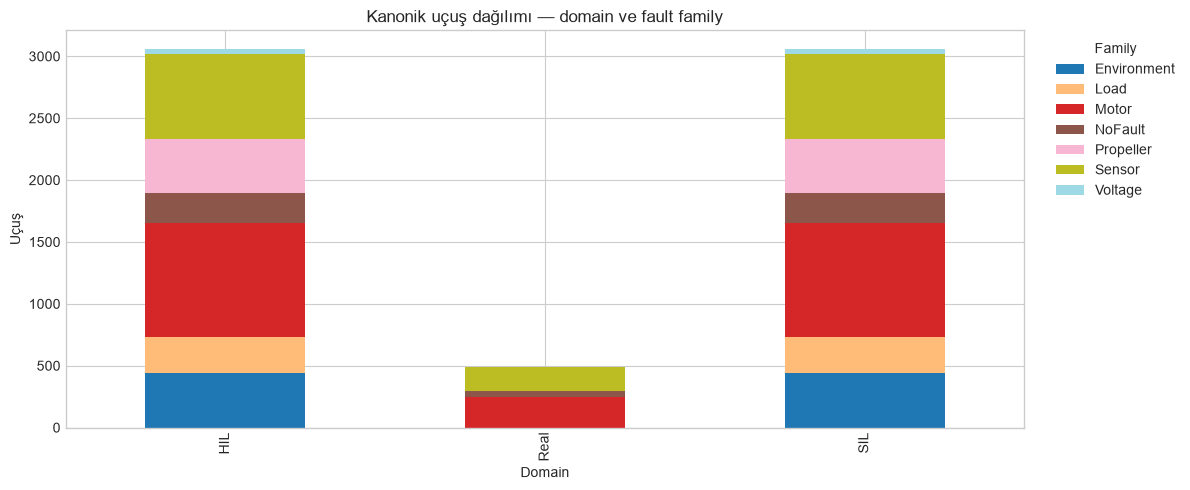

In [3]:
pivot = manifest.pivot(index="domain", columns="fault_family", values="flights").fillna(0)
display(pivot.astype(int))
ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
ax.set_title("Kanonik uçuş dağılımı — domain ve fault family")
ax.set_xlabel("Domain")
ax.set_ylabel("Uçuş")
ax.legend(title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2. AE ve TCN sağlık sonuçları

Normal-only temporal AE, beş development rotasyonu üzerinde raporlandı. TCN ise
`--development-smoke-fold 1 --epochs 3` sağlık kontrolüdür; `status=smoke_only`
olduğu için nihai model karşılaştırması veya operasyonel kanıt değildir.

**Normal-only temporal AE — 5 rotasyon ortalaması**

,politika,event_recall,recall_std,nonfault_FA/saat,FA_std,Wind_FA/saat
0,advisory,0.6984,0.0585,3.6437,1.3191,31.5374
1,critical,0.6043,0.0554,1.2788,0.3470,28.4618


**TCN — development smoke fold 1, 3 epoch**

,policy,event_recall,false_alarms_per_hour,median_detection_delay_s,flight_tp,flight_fn,flight_fp,flight_tn
0,critical,0.1368,2.4324,32.5,132,833,1,179
1,advisory,0.7140,13.5930,18.0,689,276,59,121


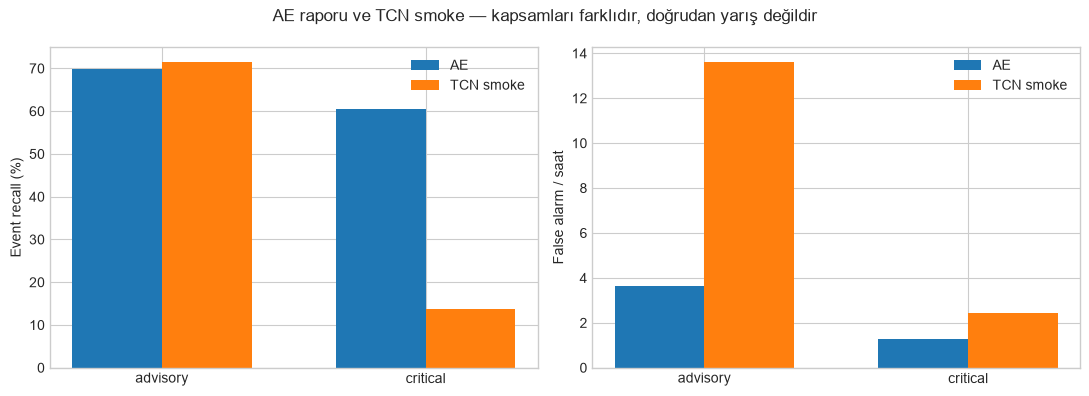

In [4]:
ae_view = ae.rename(columns={
    "policy": "politika", "recall_mean": "event_recall",
    "recall_std": "recall_std", "fa_mean": "nonfault_FA/saat",
    "fa_std": "FA_std", "wind_fa_mean": "Wind_FA/saat"
})
display(Markdown("**Normal-only temporal AE — 5 rotasyon ortalaması**"))
display(ae_view.round(4))

tcn_view = tcn[["policy", "event_recall", "false_alarms_per_hour",
                "median_detection_delay_s", "flight_tp", "flight_fn", "flight_fp", "flight_tn"]]
display(Markdown("**TCN — development smoke fold 1, 3 epoch**"))
display(tcn_view.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
policies = ae["policy"].tolist()
x = np.arange(len(policies)); width = 0.34
axes[0].bar(x-width/2, ae["recall_mean"]*100, width, label="AE")
axes[0].bar(x+width/2, tcn.set_index("policy").loc[policies, "event_recall"]*100, width, label="TCN smoke")
axes[0].set_xticks(x, policies); axes[0].set_ylabel("Event recall (%)"); axes[0].legend()
axes[1].bar(x-width/2, ae["fa_mean"], width, label="AE")
axes[1].bar(x+width/2, tcn.set_index("policy").loc[policies, "false_alarms_per_hour"], width, label="TCN smoke")
axes[1].set_xticks(x, policies); axes[1].set_ylabel("False alarm / saat"); axes[1].legend()
fig.suptitle("AE raporu ve TCN smoke — kapsamları farklıdır, doğrudan yarış değildir")
plt.tight_layout(); plt.show()

## 3. Wind/Real robustness deneyleri

Başarı ölçütleri sonuçlardan önce donduruldu. R1, W1, W2, R2 ve R3 sekiz epoch
bütçeli nested development adaylarıdır. R4, kullanıcının epoch bütçesi itirazı
üzerine ayrı sözleşmeyle yapılan validation-early-stopping convergence takibidir.

,candidate,event_recall_mean,all_nonfault_fa_per_hour_mean,wind_fa_per_hour_mean,real_motor_recall_mean,real_sensor_recall_mean,real_macro_recall_mean,real_normal_fa_per_hour_mean
0,frozen_baseline,0.6043,1.2788,28.4618,0.2020,0.0835,0.1428,0.7991
2,R1,0.5955,3.2846,28.1335,0.2388,0.2203,0.2295,12.0830
4,W1,0.1078,2.5427,7.8538,0.2388,0.2203,0.2295,12.0830
6,W2,0.5590,2.6529,17.7774,0.1061,0.1747,0.1404,3.7886
8,R2,0.5946,3.2367,27.8323,0.2337,0.2177,0.2257,11.6834
10,R3,0.5890,3.2019,27.8295,0.2327,0.2165,0.2246,11.6834
12,R4,0.5461,5.2396,28.7540,0.2939,0.2684,0.2811,12.9784


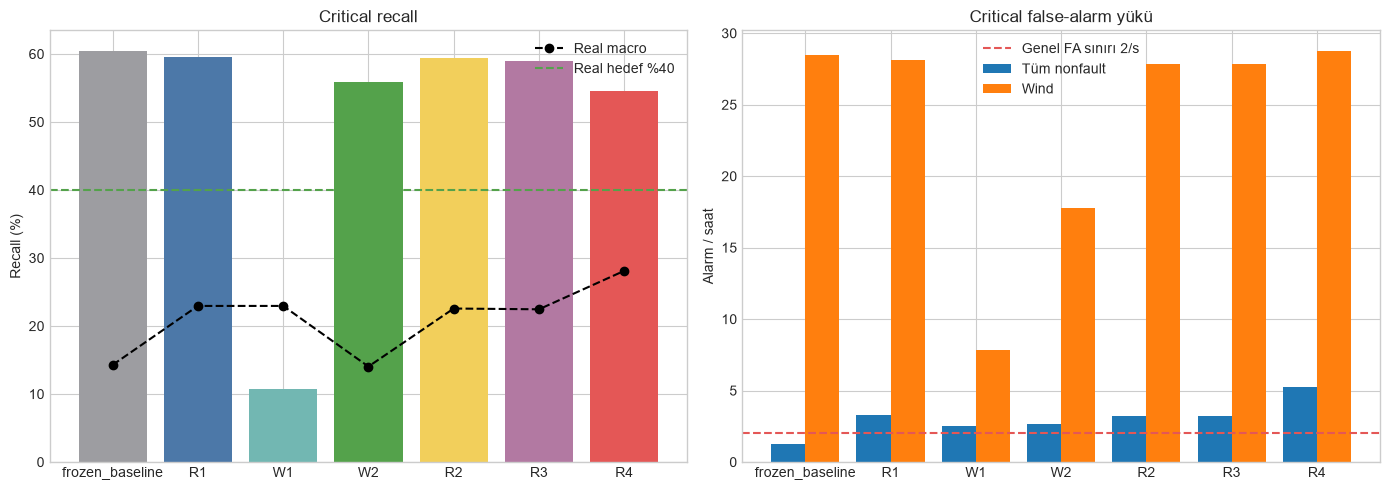

In [5]:
critical = comparison.query("policy == 'critical'").copy()
cols = ["candidate", "event_recall_mean", "all_nonfault_fa_per_hour_mean",
        "wind_fa_per_hour_mean", "real_motor_recall_mean", "real_sensor_recall_mean",
        "real_macro_recall_mean", "real_normal_fa_per_hour_mean"]
display(critical[cols].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(critical))
axes[0].bar(x, critical["event_recall_mean"]*100,
            color=[COLORS[c] for c in critical["candidate"]])
axes[0].plot(x, critical["real_macro_recall_mean"]*100, "ko--", label="Real macro")
axes[0].axhline(40, color="#54a24b", ls="--", label="Real hedef %40")
axes[0].set_xticks(x, critical["candidate"]); axes[0].set_ylabel("Recall (%)")
axes[0].set_title("Critical recall"); axes[0].legend()
axes[1].bar(x-0.2, critical["all_nonfault_fa_per_hour_mean"], 0.4, label="Tüm nonfault")
axes[1].bar(x+0.2, critical["wind_fa_per_hour_mean"], 0.4, label="Wind")
axes[1].axhline(2, color="#e45756", ls="--", label="Genel FA sınırı 2/s")
axes[1].set_xticks(x, critical["candidate"]); axes[1].set_ylabel("Alarm / saat")
axes[1].set_title("Critical false-alarm yükü"); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. R4 convergence: epoch-başına davranış

Sabit sekiz epoch yeterli değildi: rotasyona bağlı olarak en iyi checkpoint epoch
1 ile 780 arasında değişti. Seçim yalnız inner Real-NoFault validation loss ile
yapıldı; outer fault metrikleri epoch seçimine girmedi.

,rotation,initial_validation_loss,best_validation_loss,best_epoch,epochs_completed,stop_reason
0,0,7.66561,7.38685,1,13,validation_patience_exhausted
1,1,8.40317,3.93863,780,792,validation_patience_exhausted
2,2,8.71910,8.13557,217,229,validation_patience_exhausted
3,3,5.83753,5.79022,1,13,validation_patience_exhausted
4,4,7.31505,3.94362,628,640,validation_patience_exhausted


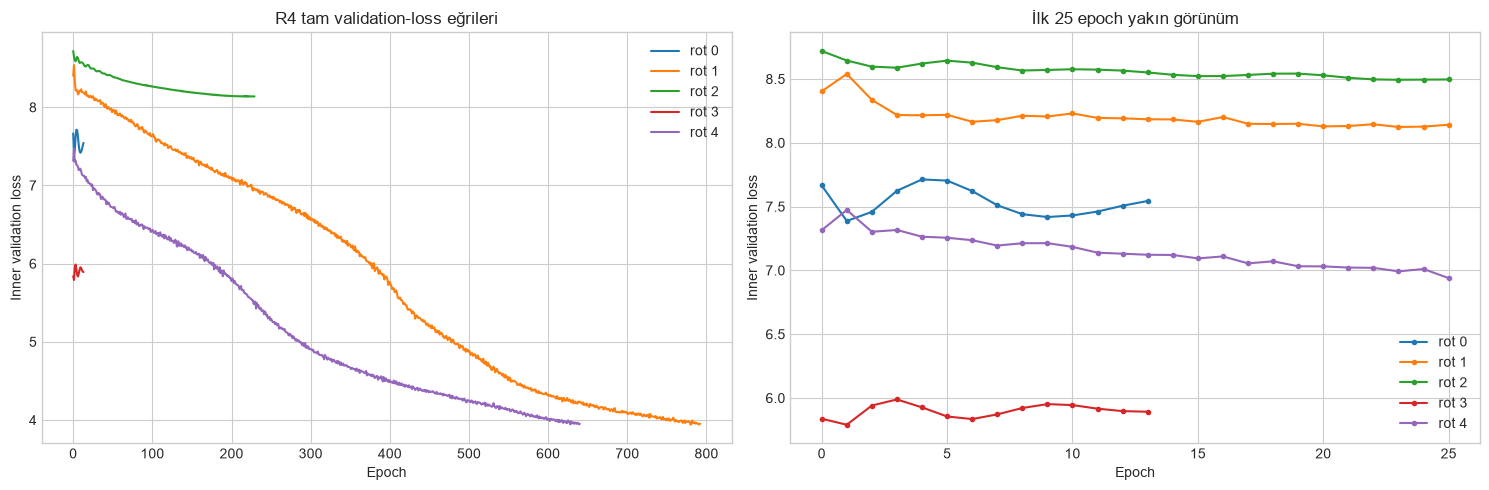

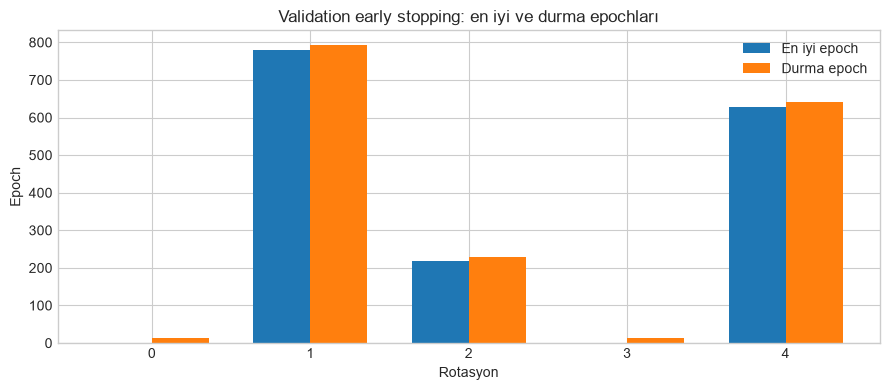

In [6]:
conv_view = convergence[["rotation", "initial_validation_loss", "best_validation_loss",
                         "best_epoch", "epochs_completed", "stop_reason"]].copy()
display(conv_view.round(5))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for rotation, group in history.groupby("rotation"):
    axes[0].plot(group["epoch"], group["validation_loss"], label=f"rot {rotation}")
    short = group[group["epoch"] <= 25]
    axes[1].plot(short["epoch"], short["validation_loss"], marker=".", label=f"rot {rotation}")
axes[0].set_title("R4 tam validation-loss eğrileri")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Inner validation loss"); axes[0].legend()
axes[1].set_title("İlk 25 epoch yakın görünüm")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Inner validation loss"); axes[1].legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(convergence)); width = 0.36
ax.bar(x-width/2, convergence["best_epoch"], width, label="En iyi epoch")
ax.bar(x+width/2, convergence["epochs_completed"], width, label="Durma epoch")
ax.set_xticks(x, convergence["rotation"]); ax.set_xlabel("Rotasyon"); ax.set_ylabel("Epoch")
ax.set_title("Validation early stopping: en iyi ve durma epochları"); ax.legend()
plt.tight_layout(); plt.show()

## 5. R4 rotasyon kararlılığı ve trade-off

Convergence Real recall’ı R3’e göre artırdı; buna karşılık genel recall düştü ve
false-alarm yükü arttı. Beş rotasyon arasındaki geniş saçılım, ortalama sonucun tek
başına kararlı model davranışı sayılmaması gerektiğini gösterir.

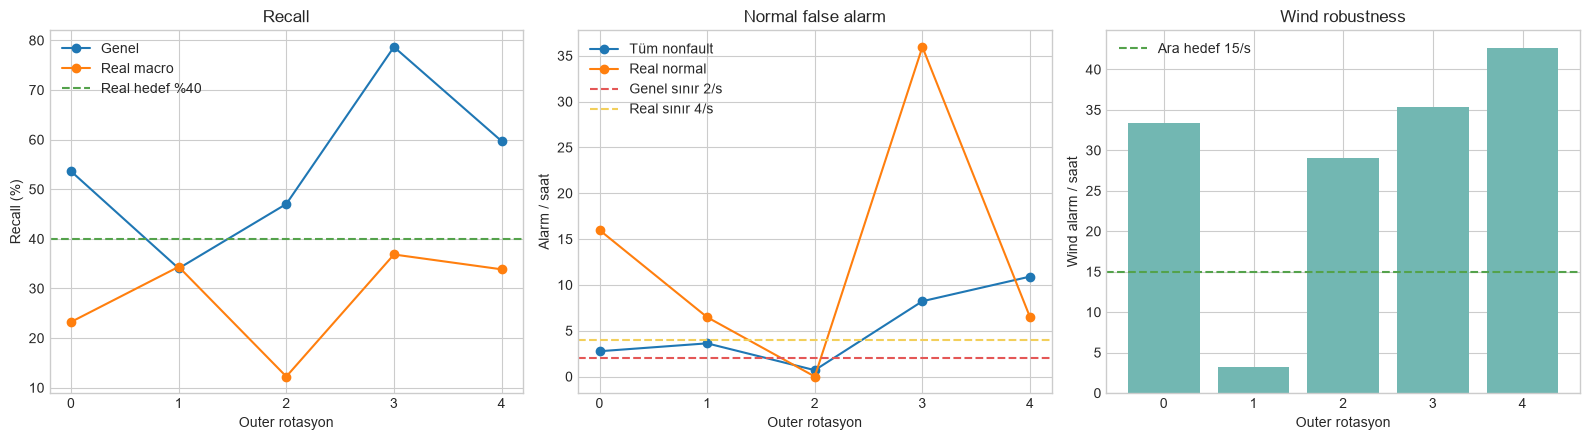

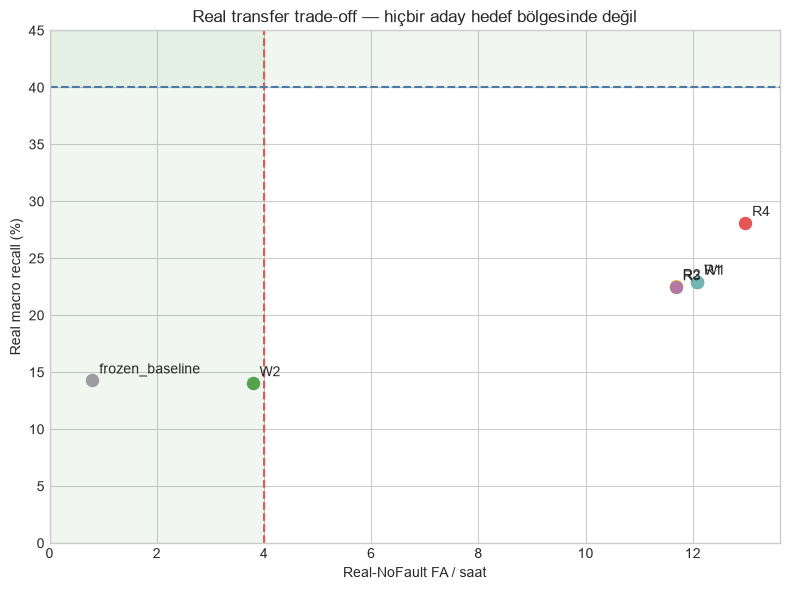

In [7]:
r4c = r4_metrics.query("policy == 'critical'").sort_values("rotation")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = r4c["rotation"]
axes[0].plot(x, r4c["event_recall"]*100, "o-", label="Genel")
axes[0].plot(x, r4c["real_macro_recall"]*100, "o-", label="Real macro")
axes[0].axhline(40, color="#54a24b", ls="--", label="Real hedef %40")
axes[0].set_ylabel("Recall (%)"); axes[0].set_title("Recall"); axes[0].legend()
axes[1].plot(x, r4c["all_nonfault_fa_per_hour"], "o-", label="Tüm nonfault")
axes[1].plot(x, r4c["real_normal_fa_per_hour"], "o-", label="Real normal")
axes[1].axhline(2, color="#e45756", ls="--", label="Genel sınır 2/s")
axes[1].axhline(4, color="#f2cf5b", ls="--", label="Real sınır 4/s")
axes[1].set_ylabel("Alarm / saat"); axes[1].set_title("Normal false alarm"); axes[1].legend()
axes[2].bar(x, r4c["wind_fa_per_hour"], color="#72b7b2")
axes[2].axhline(15, color="#54a24b", ls="--", label="Ara hedef 15/s")
axes[2].set_ylabel("Wind alarm / saat"); axes[2].set_title("Wind robustness"); axes[2].legend()
for ax in axes: ax.set_xlabel("Outer rotasyon"); ax.set_xticks(x)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.axvspan(0, 4, color="#54a24b", alpha=.08)
ax.axhspan(40, 100, color="#54a24b", alpha=.08)
for _, row in critical.iterrows():
    xval = row["real_normal_fa_per_hour_mean"]
    yval = row["real_macro_recall_mean"] * 100
    ax.scatter(xval, yval, s=75, color=COLORS[row["candidate"]])
    ax.annotate(row["candidate"], (xval, yval), xytext=(5, 5), textcoords="offset points")
ax.axvline(4, color="#e45756", ls="--"); ax.axhline(40, color="#4c78a8", ls="--")
ax.set_xlim(left=0); ax.set_ylim(0, max(45, critical["real_macro_recall_mean"].max()*115))
ax.set_xlabel("Real-NoFault FA / saat"); ax.set_ylabel("Real macro recall (%)")
ax.set_title("Real transfer trade-off — hiçbir aday hedef bölgesinde değil")
plt.tight_layout(); plt.show()

## 6. Nihai karar

R4 yalnız development convergence takibidir. Real research gate, Wind ara hedefi
ve Wind nihai hedefi geçilmedi. Locked test açılmamalı; mevcut temsil ve veriyle
operasyonel/fizibilite iddiası kurulamaz.

In [8]:
rob = summary["robustness"]
gate = rob["r4_gate"]
agg = gate["critical_aggregate"]
ci = rob["r4_bootstrap"]["policies"]["critical"]["real_macro_recall"]

decision = pd.DataFrame([
    ["Critical event recall", agg["event_recall"]["mean"], "koruma kapısı", False],
    ["Real Motor recall", agg["real_motor_recall"]["mean"], ">= 0.30", False],
    ["Real Sensor recall", agg["real_sensor_recall"]["mean"], ">= 0.30", False],
    ["Real macro recall", agg["real_macro_recall"]["mean"], ">= 0.40", False],
    ["Real-NoFault FA/saat", agg["real_normal_fa_per_hour"]["mean"], "<= 4", False],
    ["Tüm nonfault FA/saat", agg["all_nonfault_fa_per_hour"]["mean"], "<= 2", False],
    ["Wind FA/saat", agg["wind_fa_per_hour"]["mean"], "<= 15 ara hedef", False],
], columns=["Metrik", "R4 ortalama", "Ölçüt", "Geçti"])
display(decision.round(4))
print(f"Real macro cluster-bootstrap %95 GA: {ci['lower_95']:.4f}–{ci['upper_95']:.4f}")
print(f"Real research gate: {gate['real_research_gate']['passed']}")
print(f"Wind intermediate gate: {gate['wind_intermediate_gate']['passed']}")
print(f"Locked-test features read: {rob['locked_test_features_read']}")
print(f"Operational claim allowed: {rob['operational_claim_allowed']}")

,Metrik,R4 ortalama,Ölçüt,Geçti
0,Critical event recall,0.5461,koruma kapısı,False
1,Real Motor recall,0.2939,>= 0.30,False
2,Real Sensor recall,0.2684,>= 0.30,False
3,Real macro recall,0.2811,>= 0.40,False
4,Real-NoFault FA/saat,12.9784,<= 4,False
5,Tüm nonfault FA/saat,5.2396,<= 2,False
6,Wind FA/saat,28.7540,<= 15 ara hedef,False


Real macro cluster-bootstrap %95 GA: 0.2492–0.3144
Real research gate: False
Wind intermediate gate: False
Locked-test features read: False
Operational claim allowed: False


## 7. Tekrarlanabilirlik

- Kaynak kod: `rfly_full/`
- Çalıştırıcılar: `scripts/run_rfly_full_v2_*.py`
- Notebook üretici: `scripts/build_rfly_full_v2_summary_notebook.py`
- Ayrıntılı rapor: `docs/RFLYMAD_V2_CONVERGENCE_DENEY_RAPORU_20260722.md`
- Kompakt notebook verisi: `notebooks/data/rflymad_v2/`
- Ağır yerel artefakt kökü: `artifacts/rfly_full/v2/` (commit edilmez)

Son doğrulama: ilgili 44 test geçti; `archive/` değişikliği yoktu. Ham model/parquet
dosyaları ve loglar yeniden üretilebilir yerel artefakt olarak bırakıldı.

In [9]:
files = sorted(p.name for p in DATA.iterdir() if p.is_file())
pd.DataFrame({"Commit edilen özet dosya": files})

,Commit edilen özet dosya
0,ae_sweep_summary.csv
1,candidate_comparison_by_policy.csv
2,manifest_by_domain_family.csv
3,r4_convergence.csv
4,r4_rotation_metrics.csv
5,r4_training_history.csv
6,summary.json
7,tcn_smoke_metrics.csv
